# 01 — Exploratory Data Analysis (EDA)

The notebook gives a quick overview of the migraine dataset, checking its structure, key clinical variables, and basic temporal or environmental patterns to guide early modelling decisions.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(".."))

from pathlib import Path
from src.data_prep import (
    load_raw_data, get_numeric_vars,
    get_categorical_vars, compute_categorical_frequencies
)
from src.config import TARGET
from src.visualization import (
    plot_numeric_distributions, plot_numeric_correlations, 
    plot_categorical_distributions, plot_episodes_per_patient, 
    plot_median_dos_by_hatype, plot_dos_density_by_hatype, plot_boxplots
)
from src.data_prep import detect_outliers, report_outliers

# Paths
os.makedirs("../reports/figures", exist_ok=True)
os.makedirs("../reports/tables", exist_ok=True)

In [2]:
# Load raw data
df = load_raw_data("../data/raw/migraine.csv")
df.head()

,rownames,id,time,dos,hatype,age,airq,medication,headache,sex
0,1,1,-11,753,Aura,30,9.0,continuing,yes,female
1,2,1,-10,754,Aura,30,7.0,continuing,yes,female
2,3,1,-9,755,Aura,30,10.0,continuing,yes,female
3,4,1,-8,756,Aura,30,13.0,continuing,yes,female
4,5,1,-7,757,Aura,30,18.0,continuing,yes,female


In [3]:
# Structural summary
print("Shape:", df.shape)
df.info()

Shape: (4152, 10)
<class 'pandas.DataFrame'>
RangeIndex: 4152 entries, 0 to 4151
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   rownames    4152 non-null   int64  
 1   id          4152 non-null   int64  
 2   time        4152 non-null   int64  
 3   dos         4152 non-null   int64  
 4   hatype      4152 non-null   str    
 5   age         4152 non-null   int64  
 6   airq        4152 non-null   float64
 7   medication  4152 non-null   str    
 8   headache    4152 non-null   str    
 9   sex         4152 non-null   str    
dtypes: float64(1), int64(5), str(4)
memory usage: 324.5 KB


In [4]:
# Numeric summary
NUMERIC_VARS = get_numeric_vars(df)
summary = df[NUMERIC_VARS].describe().T
summary.to_csv("../reports/tables/numeric_summary.csv", index=True)
display(summary)

,count,mean,std,min,25%,50%,75%,max
rownames,4152.0,2076.500000,1198.723488,1.0,1038.75,2076.5,3114.25,4152.0
id,4152.0,66.386802,39.121812,1.0,33.00,67.0,100.00,133.0
time,4152.0,15.455684,21.737211,-29.0,3.00,12.0,24.00,99.0
dos,4152.0,646.705925,335.770123,98.0,384.00,623.0,950.00,1239.0
age,4152.0,42.363921,11.201244,18.0,33.00,44.0,50.00,66.0
airq,4152.0,24.826012,9.514274,3.0,18.00,24.0,29.00,73.0


In [5]:
# Categorical frequencies
CATEGORICAL_VARS = get_categorical_vars(df)
freq_table = compute_categorical_frequencies(df, CATEGORICAL_VARS)
freq_table.to_csv("../reports/tables/categorical_frequencies.csv", index=True)
display(freq_table)

,variable,category,frequency,percentage
0,hatype,No Aura,1985,47.81
1,hatype,Aura,1710,41.18
2,hatype,Mixed,457,11.01
3,medication,continuing,2386,57.47
4,medication,reduced,981,23.63
5,medication,none,785,18.91
6,headache,yes,2666,64.21
7,headache,no,1486,35.79
8,sex,female,3545,85.38
9,sex,male,607,14.62


In [6]:
# Target prevalence
target_counts = df[TARGET].value_counts() 
target_percent = df[TARGET].value_counts(normalize=True) * 100 

prevalence_df = pd.DataFrame({ "n": target_counts, "%": target_percent.round(2) }) 
prevalence_df.to_csv("../reports/tables/target_prevalence.csv", index=True)
display(prevalence_df)

,n,%
headache,,
yes,2666,64.21
no,1486,35.79


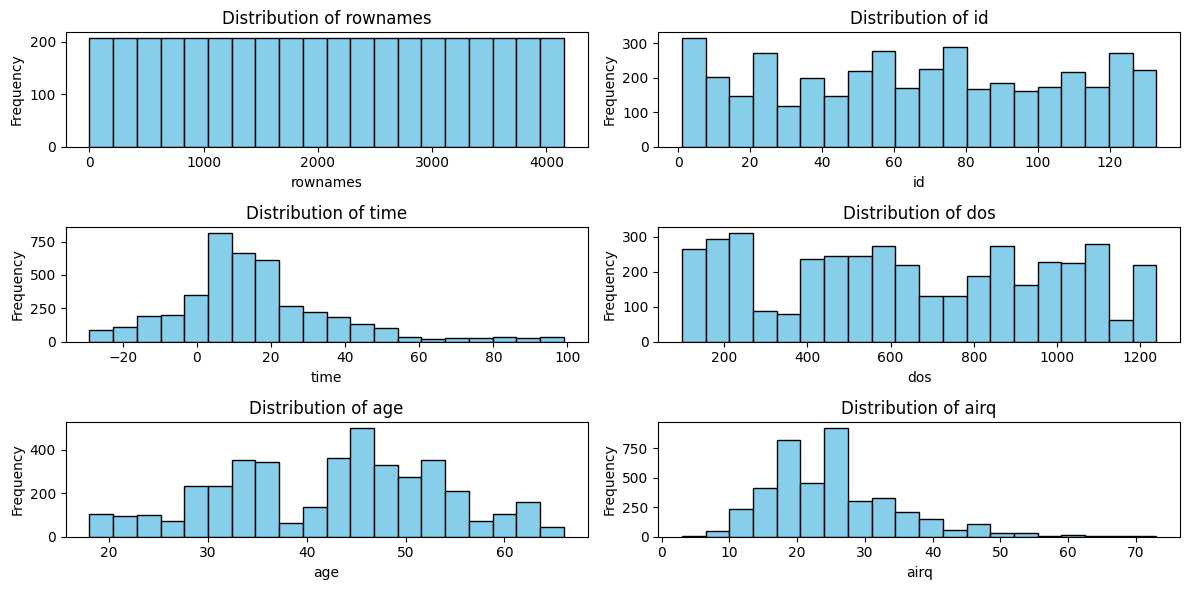

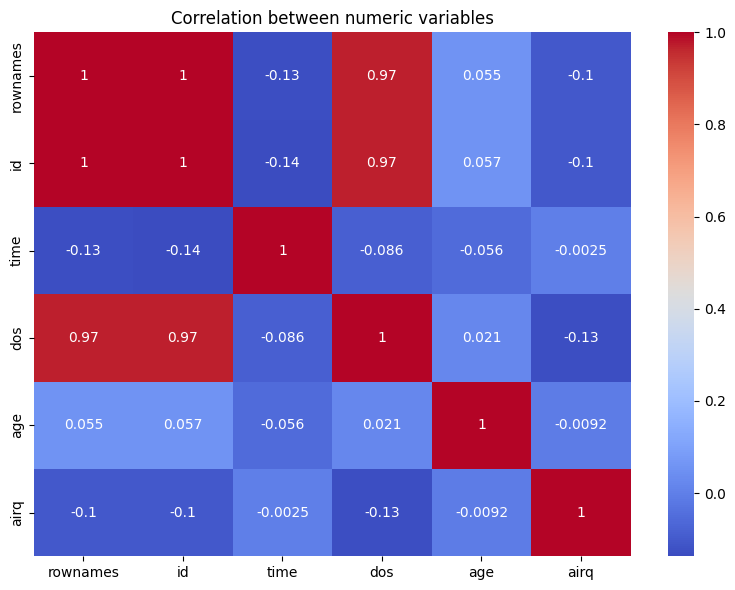

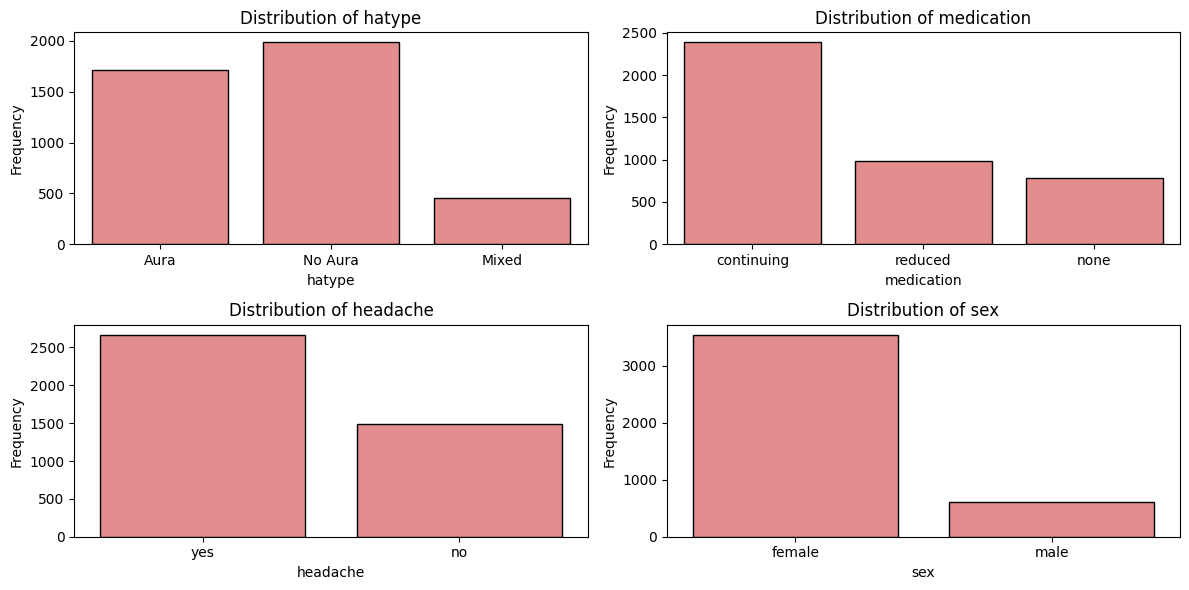

In [7]:
# Numeric distributions
fig = plot_numeric_distributions(df, NUMERIC_VARS)
fig.savefig("../reports/figures/numeric_distributions.png", dpi=300)

# Numeric correlations
fig = plot_numeric_correlations(df, NUMERIC_VARS)
fig.savefig("../reports/figures/numeric_correlations.png", dpi=300)

# Categorical distributions
fig = plot_categorical_distributions(df, CATEGORICAL_VARS)
fig.savefig("../reports/figures/categorical_distributions.png", dpi=300)

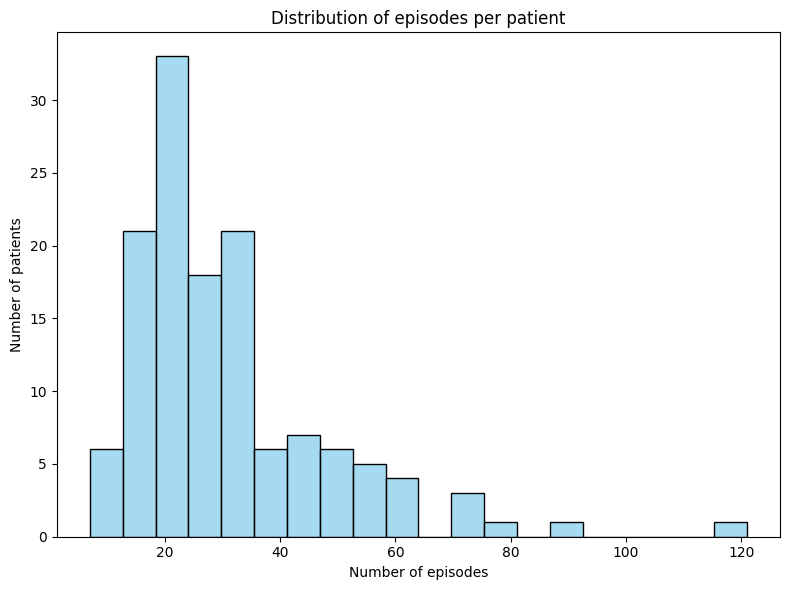

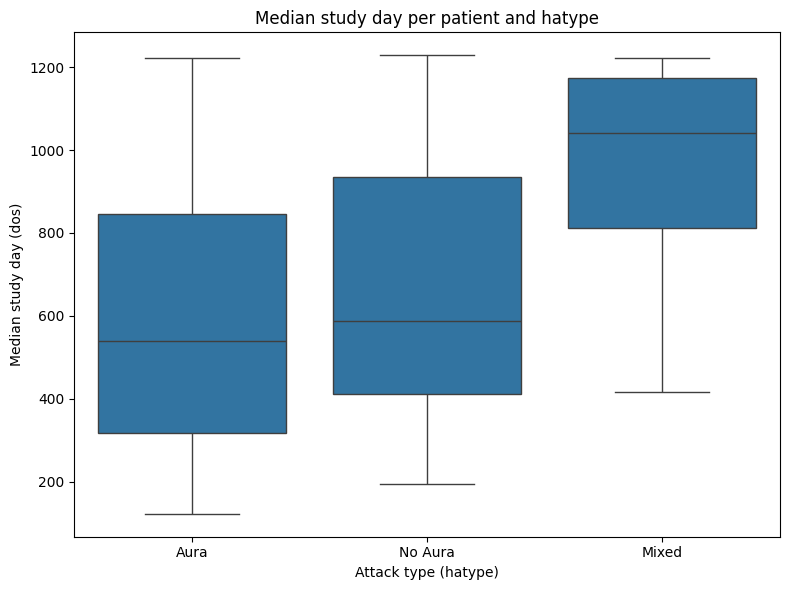

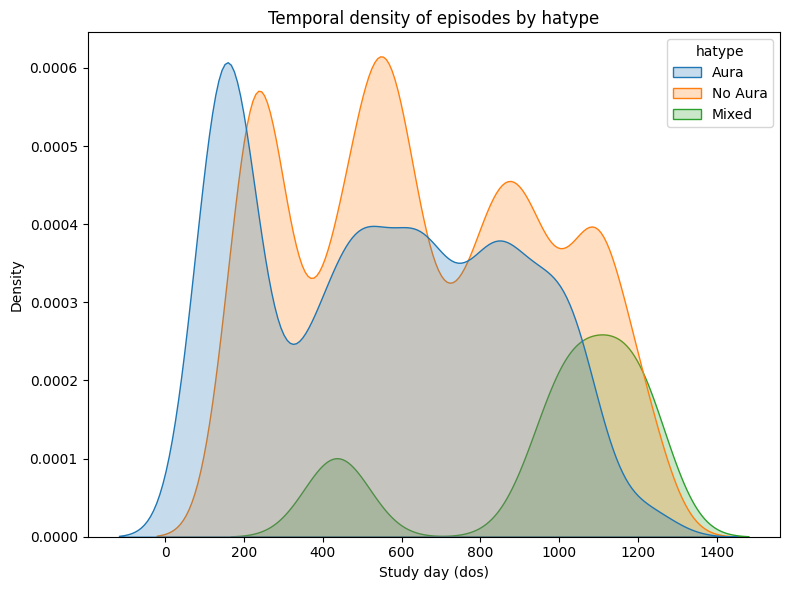

In [8]:
# Episodes per patient
fig = plot_episodes_per_patient(df)
fig.savefig("../reports/figures/episodes_per_patient.png", dpi=300)

# Median 'dos' per patient and hatype
fig = plot_median_dos_by_hatype(df)
fig.savefig("../reports/figures/median_dos_by_hatype.png", dpi=300)

# Temporal density of 'dos' by hatype
fig = plot_dos_density_by_hatype(df)
fig.savefig("../reports/figures/dos_density_by_hatype.png", dpi=300)

rownames: 0 outliers


,rownames,id,time,dos,hatype,age,airq,medication,headache,sex


id: 0 outliers


,rownames,id,time,dos,hatype,age,airq,medication,headache,sex


time: 210 outliers


...

,rownames,id,time,dos,hatype,age,airq,medication,headache,sex


age: 0 outliers


,rownames,id,time,dos,hatype,age,airq,medication,headache,sex


airq: 157 outliers


,rownames,id,time,dos,hatype,age,airq,medication,headache,sex
329,330,8,15,226,Aura,43,48.0,continuing,yes,female
330,331,8,16,227,Aura,43,53.0,continuing,yes,female
460,461,12,4,187,No Aura,24,59.0,reduced,yes,female
462,463,12,6,189,No Aura,24,49.0,reduced,yes,female
463,464,12,10,193,No Aura,24,59.0,reduced,yes,female


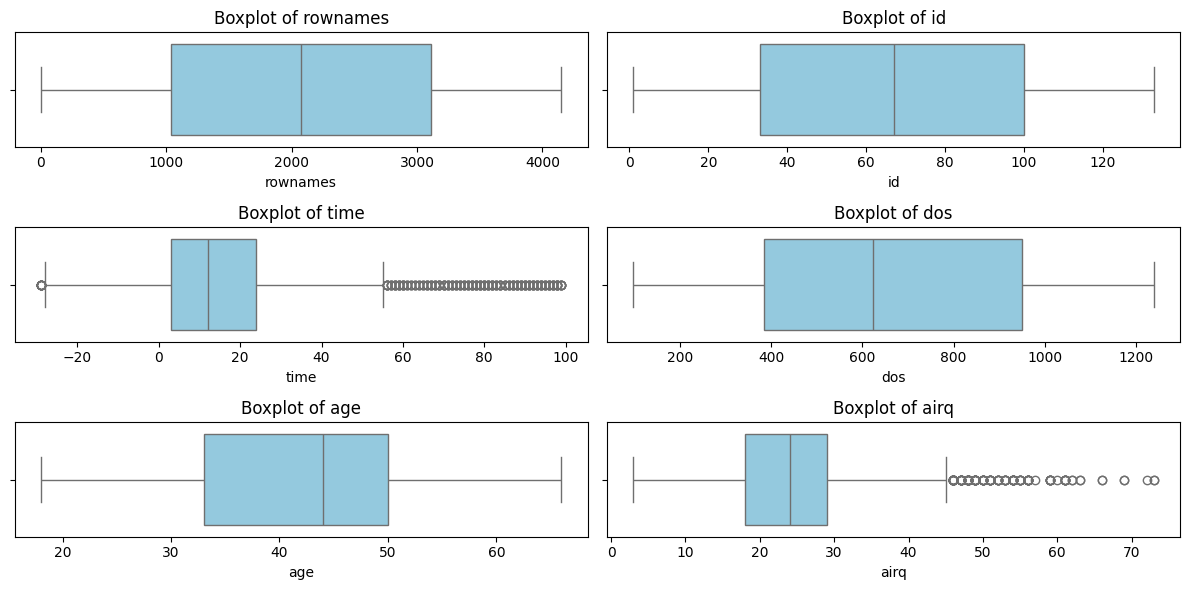

In [9]:
# Outlier detection
outlier_info = report_outliers(df, NUMERIC_VARS)

for col, info in outlier_info.items():
    outliers_df = info["outliers"]
    print(f"{col}: {len(outliers_df)} outliers") 
    display(outliers_df.head())
    outliers_df.to_csv(f"../reports/tables/outliers_{col}.csv", index=False)

# Boxplots
fig = plot_boxplots(df, NUMERIC_VARS)
fig.savefig("../reports/figures/outliers_boxplots.png", dpi=300)